# Деревья решений и Random Forest

Рассматриваются две задачи:

1. Классификация на датасете `Wine`.
2. Регрессия на датасете `Diabetes`.

Деревья решений работают и с классами, и с числовой целевой переменной,
но качество и поведение модели в этих режимах различаются.


## Датасет Wine

Датасет `Wine` содержит `178` объектов и `13` признаков.
Целевая переменная `target` - сорт вина.

Краткое описание признаков:

- `alcohol` - содержание алкоголя.
- `malic_acid` - содержание яблочной кислоты.
- `ash` - зольность.
- `alcalinity_of_ash` - щёлочность золы.
- `magnesium` - содержание магния.
- `total_phenols` - общее содержание фенолов.
- `flavanoids` - содержание флавоноидов.
- `nonflavanoid_phenols` - содержание нефлавоноидных фенолов.
- `proanthocyanins` - содержание проантоцианидинов.
- `color_intensity` - интенсивность цвета.
- `hue` - оттенок цвета.
- `od280/od315_of_diluted_wines` - оптическая плотность разведённого вина.
- `proline` - содержание пролина.


## Датасет Diabetes

Датасет `Diabetes` содержит `442` объекта и `10` признаков.
Целевая переменная `target` - количественная мера прогрессирования диабета.

Краткое описание признаков:

- `age` - возраст пациента.
- `sex` - пол пациента.
- `bmi` - индекс массы тела.
- `bp` - среднее артериальное давление.
- `s1` - общий холестерин.
- `s2` - липопротеины низкой плотности.
- `s3` - липопротеины высокой плотности.
- `s4` - отношение общего холестерина к HDL.
- `s5` - логарифм уровня триглицеридов.
- `s6` - уровень глюкозы в крови.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_wine, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine["target"] = wine.target

diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes["target"] = diabetes.target


## 1. Классификация: Decision Tree и Random Forest

Цель - по химическим характеристикам вина определить сорт.


### Подготовка данных

Формируются признаки и целевая переменная, затем данные делятся на train/test.
Дополнительно выполняется стандартизация признаков.


In [7]:
display(df_wine.head())
print("Распределение классов:")
print(df_wine["target"].value_counts().sort_index())

X_wine = df_wine.drop(columns=["target"])
y_wine = df_wine["target"]

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine,
)

scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Распределение классов:
target
0    59
1    71
2    48
Name: count, dtype: int64


### Обучение моделей

Обучаются `DecisionTreeClassifier` и `RandomForestClassifier`.


In [8]:
clf_tree = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_leaf=2)
clf_tree.fit(X_train_wine_scaled, y_train_wine)

clf_rf = RandomForestClassifier(random_state=42, n_estimators=100)
clf_rf.fit(X_train_wine_scaled, y_train_wine)


RandomForestClassifier(random_state=42)

### Метрики и визуализация

Для обеих моделей выводятся `accuracy`, classification report и матрицы ошибок.

Как читать матрицу ошибок:

- строки соответствуют реальным классам;
- столбцы соответствуют предсказанным классам;
- значения на главной диагонали - правильные классификации;
- значения вне диагонали - ошибки модели.

Ниже также строится визуализация дерева решений по первым трём уровням и график важности признаков случайного леса.


Accuracy (Decision Tree): 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Accuracy (Random Forest): 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



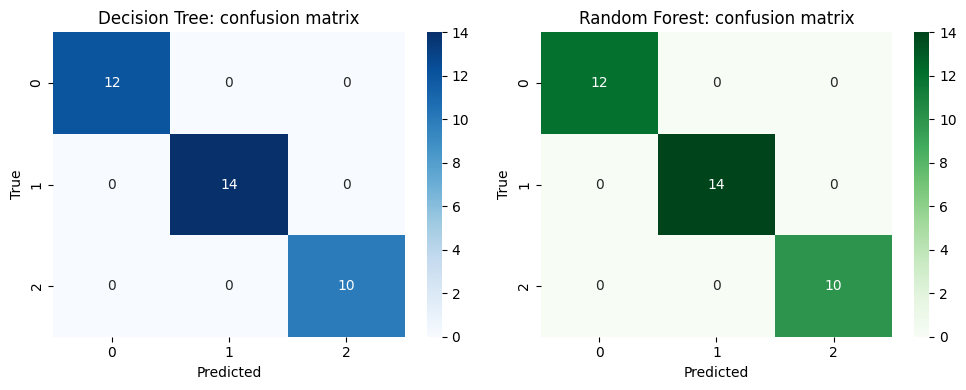

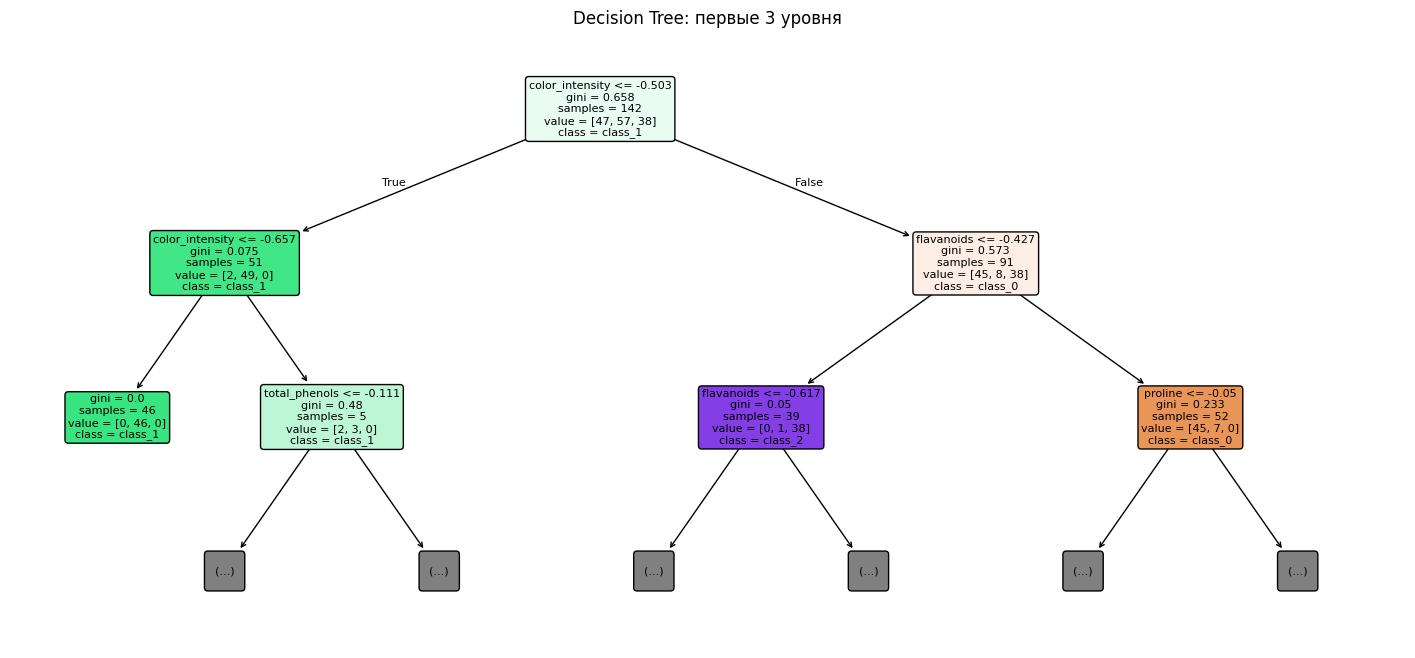

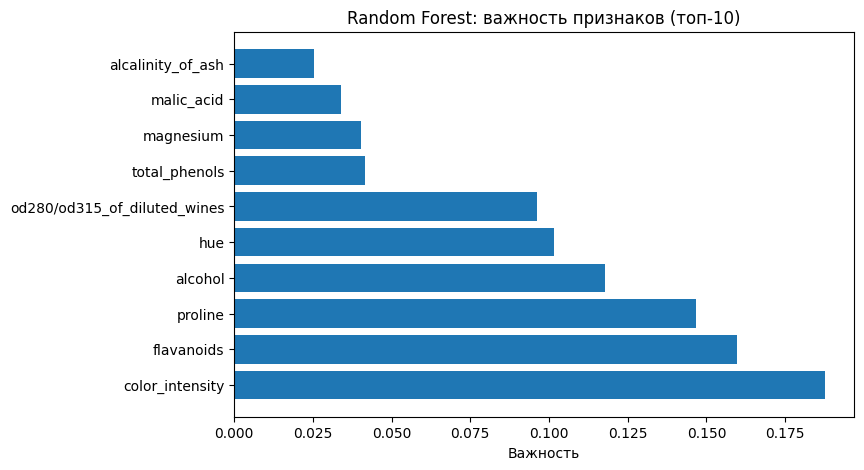

In [9]:
y_pred_tree = clf_tree.predict(X_test_wine_scaled)
y_pred_rf = clf_rf.predict(X_test_wine_scaled)

acc_tree = accuracy_score(y_test_wine, y_pred_tree)
acc_rf = accuracy_score(y_test_wine, y_pred_rf)

cm_tree = confusion_matrix(y_test_wine, y_pred_tree)
cm_rf = confusion_matrix(y_test_wine, y_pred_rf)

print(f"Accuracy (Decision Tree): {acc_tree:.3f}")
print(classification_report(y_test_wine, y_pred_tree))
print(f"Accuracy (Random Forest): {acc_rf:.3f}")
print(classification_report(y_test_wine, y_pred_rf))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues", ax=axs[0])
axs[0].set_title("Decision Tree: confusion matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axs[1])
axs[1].set_title("Random Forest: confusion matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 8))
plot_tree(
    clf_tree,
    max_depth=2,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree: первые 3 уровня")
plt.show()

importances = clf_rf.feature_importances_
indices_top = np.argsort(importances)[-10:]
top_n = len(indices_top)

plt.figure(figsize=(8, 5))
plt.barh(range(top_n), importances[indices_top][::-1])
plt.yticks(range(top_n), [df_wine.columns[i] for i in indices_top][::-1])
plt.xlabel("Важность")
plt.title("Random Forest: важность признаков (топ-10)")
plt.show()


### Краткий вывод по классификации

По текущему запуску и `Decision Tree`, и `Random Forest` получили `accuracy = 1.000`
на тестовой выборке из `36` объектов.

Матрицы ошибок соответствуют этому результату: значения сосредоточены на главной диагонали,
ошибок классификации на test-выборке нет.

График дерева по первым трём уровням показывает, какие признаки используются в верхних разбиениях,
то есть какие решения модель принимает раньше всего.


## 2. Регрессия: дерево решений на Diabetes

Цель - предсказать числовой показатель прогрессирования диабета.
Для улучшения качества используется подбор гиперпараметров через `GridSearchCV`.


### Подготовка данных

Формируются признаки и целевая переменная, затем выполняется train/test split.
Переменные из классификационной части не используются.


In [10]:
display(df_diabetes.head())

X_reg = df_diabetes.drop(columns=["target"])
y_reg = df_diabetes["target"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Обучение модели

Подбираются гиперпараметры дерева решений:

- `max_depth`;
- `min_samples_split`;
- `min_samples_leaf`;
- `ccp_alpha`.

Отбор выполняется по кросс-валидации на train-выборке.


In [11]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
grid_tree.fit(X_train_reg, y_train_reg)

tree_reg = grid_tree.best_estimator_


### Метрики и интерпретация графика

Рассчитываются `MSE`, `MAE`, `MAPE` и `R^2`.

Как читать график `фактические vs предсказанные`:

- по оси `X` отложены реальные значения;
- по оси `Y` отложены предсказанные значения;
- диагональ означает идеальное совпадение;
- чем дальше точка от диагонали, тем больше ошибка.

У дерева решений для регрессии предсказания формируются как постоянные значения в листьях,
поэтому зависимость получается ступенчатой. Если `R^2` низкий, плотного расположения точек
вдоль диагонали не будет.


Лучшие гиперпараметры:
{'ccp_alpha': 0.0, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
MSE: 3735.50
MAE: 49.37
MAPE: 0.456
R^2: 0.295


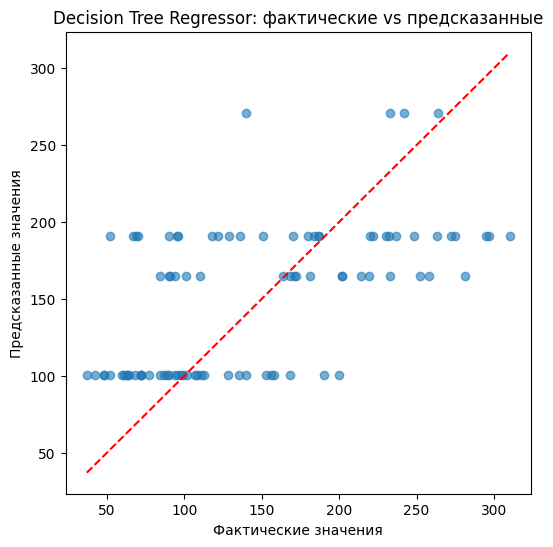

In [12]:
y_pred_tree_reg = tree_reg.predict(X_test_reg)

mse_r = mean_squared_error(y_test_reg, y_pred_tree_reg)
mae_r = mean_absolute_error(y_test_reg, y_pred_tree_reg)
mape_r = mean_absolute_percentage_error(y_test_reg, y_pred_tree_reg)
r2_r = r2_score(y_test_reg, y_pred_tree_reg)

print("Лучшие гиперпараметры:")
print(grid_tree.best_params_)
print(f"MSE: {mse_r:.2f}")
print(f"MAE: {mae_r:.2f}")
print(f"MAPE: {mape_r:.3f}")
print(f"R^2: {r2_r:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_tree_reg, alpha=0.6)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="red",
    linestyle="--",
)
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Decision Tree Regressor: фактические vs предсказанные")
plt.show()


### Краткий вывод по регрессии

По текущему запуску после подбора гиперпараметров получены значения `MSE = 3735.50`,
`MAE = 49.37`, `MAPE = 0.456`, `R^2 = 0.295`.

По сравнению с базовым деревом, у которого ранее были `MSE = 4976.80`, `MAE = 54.53`,
`MAPE = 0.454`, `R^2 = 0.061`, улучшились `MSE`, `MAE` и `R^2`.
Значение `MAPE` осталось на близком уровне и немного выросло.

По сравнению с линейной регрессией дерево всё ещё слабее,
поскольку у линейной модели `MSE = 2900.19` и `R^2 = 0.453`.

Подбор гиперпараметров сработал корректно, но полностью проблему качества не снял:
дерево после настройки стало лучше базовой версии, однако линейной регрессии по точности не достигло.
